In [2]:
import numpy as np
import cv2
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
# Config for Segmented Characters
CHAR_IMAGE_HEIGHT = 70
CHAR_IMAGE_WIDTH = 50

In [4]:
def remove_lines(img) -> np.ndarray: 
    img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lines = np.where(img_grey == 0, 255, 0).astype(np.uint8)
    # Expand lines to 3 channels
    lines = cv2.merge([lines, lines, lines])
    processed = img + lines

    # Convert to float for computation
    img = img.astype(float)
    
    # Compute local mean for each channel using a 3x3 filter
    avg_img = np.zeros_like(img)
    for c in range(3):
        avg_img[..., c] = uniform_filter(processed[..., c], size=3, mode='reflect')
    
    # Create mask for black pixels
    mask_black = np.all(img == 0, axis=-1)

    # Replace black pixels with local averages
    img[mask_black] = avg_img[mask_black]

    # Clip and convert back
    return np.clip(img, 0, 255).astype(np.uint8)

In [5]:
import numpy as np
import cv2
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

def segment_by_color(
    img: np.ndarray, 
    eps: float = 0.5,           # DBSCAN neighborhood radius (tuned)
    min_pixel_area: int = 31,   # Minimum pixel count per final blob
    db_min_samples: int = 27,   # Minimum pixels to form a cluster
    spatial_weight: float = 0.1  # Controls importance of x,y distance
) -> tuple[int, list[np.ndarray]]:
    """
    Segments a CAPTCHA image using spatial + color (hue) clustering.

    - Converts image to HSV and filters out white background.
    - Maps hue to (cos, sin) to handle circular hue wraparound.
    - Clusters in 4D space: (x, y, cos(hue), sin(hue)) using DBSCAN.
    - Merges small gaps vertically to connect 'i' stems/dots.
    
    Args:
        img: Input RGB (or BGR) image as NumPy array.
        eps: DBSCAN neighborhood size (after scaling).
        min_pixel_area: Minimum size for a valid character blob.
        db_min_samples: Minimum samples for DBSCAN cluster.
        spatial_weight: Relative importance of spatial vs color distance.
    Returns:
        (character_count, list_of_character_images)
    """
    # --- 1. Convert to HSV ---
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s_channel = hsv[:, :, 1]
    v_channel = hsv[:, :, 2]

    # --- 2. Filter out white background ---
    s_thresh = 5
    v_thresh = 250
    bg_mask = cv2.bitwise_and(
        cv2.compare(s_channel, s_thresh, cv2.CMP_LT),
        cv2.compare(v_channel, v_thresh, cv2.CMP_GT)
    )
    fg_mask = cv2.bitwise_not(bg_mask)

    y_coords, x_coords = np.where(fg_mask > 0)
    if len(y_coords) < min_pixel_area:
        return 0, []

    # --- 3. Get hue values and map to circular coords ---
    hues = hsv[y_coords, x_coords, 0].astype(np.float32) / 180.0  # normalize hue to [0,1]
    hue_x = np.cos(2 * np.pi * hues)
    hue_y = np.sin(2 * np.pi * hues)

    # --- 4. Combine features: spatial + color ---
    features = np.column_stack([
        y_coords, 
        x_coords,
        hue_x,
        hue_y
    ])

    # --- 5. Normalize features (to make x,y comparable to hue) ---
    features_scaled = StandardScaler().fit_transform(features)
    features_scaled[:, :2] *= spatial_weight  # re-apply spatial weight after scaling

    # --- 6. DBSCAN clustering ---
    db = DBSCAN(eps=eps, min_samples=db_min_samples).fit(features_scaled)
    labels = db.labels_
    unique_labels = set(labels)

    char_images = []
    char_bboxes = []

    # --- 7. Build masks for each cluster ---
    for label in unique_labels:
        if label == -1:
            continue  # skip noise

        cluster_mask = np.zeros(img.shape[:2], dtype="uint8")
        cluster_idx = np.where(labels == label)[0]
        cluster_y = y_coords[cluster_idx]
        cluster_x = x_coords[cluster_idx]
        cluster_mask[cluster_y, cluster_x] = 255

        # --- 8. Morphological close (vertical kernel) ---
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 5))
        closed_mask = cv2.morphologyEx(cluster_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

        # --- 9. Find connected components (characters) ---
        num_comp, comp_labels, stats, _ = cv2.connectedComponentsWithStats(closed_mask, 8, cv2.CV_32S)
        if num_comp <= 1:
            continue

        for i in range(1, num_comp):
            area = stats[i, cv2.CC_STAT_AREA]
            if area < min_pixel_area:
                continue

            final_mask = (comp_labels == i)
            y_pix, x_pix = np.where(final_mask)
            if len(x_pix) == 0:
                continue

            x_min = x_pix.min()

            # Create character image
            char_img = np.full_like(img, 255, dtype=np.uint8)
            char_img[final_mask] = img[final_mask]

            char_images.append(char_img)
            char_bboxes.append(x_min)

    # --- 10. Sort characters left-to-right ---
    if char_bboxes:
        sorted_idx = np.argsort(char_bboxes)
        char_images = [char_images[i] for i in sorted_idx]

    return len(char_images), char_images

In [6]:
from sklearn.cluster import DBSCAN

def segment_by_value(
    img: np.ndarray, 
    eps: int = 5,  # <-- Tuned parameter
    min_pixel_area: int = 31,  # <-- Tuned parameter
    db_min_samples: int = 27, # <-- Tuned parameter
) -> tuple[int, list[np.ndarray]]:
    """
    Segments a CAPTCHA image using color clustering:
    - Uses a VERTICAL kernel (3,5) to connect 'i' dots/stems
    without merging horizontally-adjacent chars (like '7bm').
    
    Args:
        img: The input RGB image (as a NumPy array).
        eps: The max distance (eps) for one cluster.
        min_pixel_area: Min pixels for a *final spatial component*.
        db_min_samples: Min pixels to form a *color cluster*.
        spatial_weight: Weighting for spatial vs color distance.
    
    Returns:
        A tuple of (character_count, list_of_character_images).
    """
    
    # --- 1. Convert to HSV ---
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s_channel = hsv[:, :, 1]
    v_channel = hsv[:, :, 2]

    # --- 2. Filter out white background ---
    s_thresh = 5
    v_thresh = 250
    bg_mask = cv2.bitwise_and(
        cv2.compare(s_channel, s_thresh, cv2.CMP_LT),
        cv2.compare(v_channel, v_thresh, cv2.CMP_GT)
    )
    fg_mask = cv2.bitwise_not(bg_mask)

    y_coords, x_coords = np.where(fg_mask > 0)
    if len(y_coords) < min_pixel_area:
        return 0, []

    values = hsv[y_coords, x_coords, 2].astype(np.float32)
    features = values.reshape(-1, 1)

    # --- 6. DBSCAN clustering ---
    db = DBSCAN(eps=eps, min_samples=db_min_samples).fit(features)
    labels = db.labels_
    unique_labels = set(labels)

    temp_char_images = []
    temp_char_bboxes = []
    char_images = []
    char_bboxes = []
    
    # 5. Create an image for each color cluster (character)
    for label in unique_labels:
        if label == -1: # Skip noise
            continue
        
        cluster_mask = np.zeros(img.shape[:2], dtype="uint8")
        
        cluster_indices = np.where(labels == label)[0]
        cluster_y = y_coords[cluster_indices]
        cluster_x = x_coords[cluster_indices]
        
        cluster_mask[cluster_y, cluster_x] = 255
        
        # 6. Clean up the mask (connect nearby parts of the same color)

        # A (5, 7) kernel is 5px wide and 7px tall.
        # It's more aggressive at closing VERTICAL gaps (like 'i')
        # than horizontal gaps (like '7bm').
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 7)) 
        closed_mask = cv2.morphologyEx(cluster_mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        
        # 7. Find ALL characters from the color cluster mask
        num_components, comp_labels, stats, _ = \
            cv2.connectedComponentsWithStats(closed_mask, 8, cv2.CV_32S)
        
        if num_components <= 1: # Only background
            continue
        
        # Loop through all found components (skip 0, the background)
        for i in range(1, num_components):
            
            # 8. Filter small components by area
            area = stats[i, cv2.CC_STAT_AREA] 
            if area < min_pixel_area:
                continue
                
            # 9. Extract this component as a character
            final_mask = (comp_labels == i)
            
            _, x_pix = np.where(final_mask)
            if len(x_pix) == 0:
                continue
            
            x_min = x_pix.min()
            
            char_img = np.full_like(img, 255, dtype=np.uint8)
            char_img[final_mask] = img[final_mask]
            
            temp_char_images.append(char_img)
            temp_char_bboxes.append(x_min)

    pixel_counts = [np.sum((img < 255).any(axis=-1)) for img in temp_char_images]
    pixel_area_threshold = np.max(pixel_counts) * 0.7

    for img, bbox, pcount in zip(temp_char_images, temp_char_bboxes, pixel_counts):
        if pcount >= pixel_area_threshold:
            char_images.append(img)
            char_bboxes.append(bbox)

    # 10. Sort characters left-to-right
    if char_bboxes:
        sorted_indices = np.argsort(char_bboxes)
        char_images = [char_images[i] for i in sorted_indices]
    
    return len(char_images), char_images

In [7]:
def detect_chars_and_sizes(img: np.ndarray,
                              min_area: int = 20,
                              connectivity: int = 8,
                              s_thresh: int = 5,
                              v_thresh: int = 250,
                              display: bool = True):
    """
    Detect character bounding boxes on a CAPTCHA-like image, plot boxes on the image
    and annotate each box with its size (width x height) and pixel area.

    Args:
        img: BGR image (numpy.ndarray) as read by cv2.imread.
        min_area: minimum component pixel area to keep.
        connectivity: 4 or 8 for connected components.
        s_thresh, v_thresh: thresholds to detect white background (same logic as other functions).
        display: if True show matplotlib plot, otherwise only return boxes.

    Returns:
        boxes: list of tuples (x, y, w, h, area) for each detected box (left, top, width, height, area).
    """
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    # Convert to HSV and compute foreground mask (non-white pixels)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s_channel = hsv[:, :, 1]
    v_channel = hsv[:, :, 2]

    bg_mask = cv2.bitwise_and(
        cv2.compare(s_channel, s_thresh, cv2.CMP_LT),
        cv2.compare(v_channel, v_thresh, cv2.CMP_GT)
    )
    fg_mask = cv2.bitwise_not(bg_mask)  # 0 background, 255 foreground

    # Ensure binary 0/255
    _, fg_bin = cv2.threshold(fg_mask, 0, 255, cv2.THRESH_BINARY)

    # Connected components to get bounding boxes and areas
    num_components, comp_labels, stats, centroids = \
        cv2.connectedComponentsWithStats(fg_bin, connectivity, cv2.CV_32S)

    boxes = []
    for i in range(1, num_components):  # skip background label 0
        area = int(stats[i, cv2.CC_STAT_AREA])
        if area < min_area:
            continue
        x = int(stats[i, cv2.CC_STAT_LEFT])
        y = int(stats[i, cv2.CC_STAT_TOP])
        w = int(stats[i, cv2.CC_STAT_WIDTH])
        h = int(stats[i, cv2.CC_STAT_HEIGHT])
        boxes.append({'x': x, 'y': y, 'w': w, 'h': h, 'area': area})

    # Optionally display on matplotlib
    if display:
        # Convert BGR -> RGB for plotting
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        _, ax = plt.subplots(figsize=(10, 4))
        ax.imshow(img_rgb)
        ax.set_axis_off()

        for box in boxes:
            x, y, w, h, area = box['x'], box['y'], box['w'], box['h'], box['area']
            rect = Rectangle((x, y), w, h,
                             linewidth=1.5, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            # Annotate with size and area. Use a contrasting bbox for readability.
            label = f"{w}x{h}\n{area}px"
            ax.text(x, y - 2, label,
                    color='white', fontsize=8,
                    verticalalignment='bottom',
                    bbox=dict(facecolor='black', alpha=0.6, pad=1))
        plt.tight_layout()
        plt.show()

    return boxes

In [8]:
def crop_and_resize_characters(img: np.ndarray,
                               min_area: int = 20,
                               padding: int = 5,
                               dilate_kernel_size: int = 5,
                               dilate_iters: int = 2,
                               s_thresh: int = 5,
                               v_thresh: int = 250,
                               char_image_size: tuple[int, int] = (CHAR_IMAGE_WIDTH, CHAR_IMAGE_HEIGHT)
    ) -> tuple[list[np.ndarray], list[tuple[int,int,int,int,int]]]:
    """
    Detect loose character boundaries and return cropped character images.

    Returns:
      (crops, boxes)
      - crops: list of BGR cropped images (numpy.ndarray)
      - boxes: list of tuples (x, y, w, h, area)
    """
    h_img, w_img = img.shape[:2]

    # HSV foreground (non-white) mask (same logic used elsewhere)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s_channel = hsv[:, :, 1]
    v_channel = hsv[:, :, 2]
    bg_mask = cv2.bitwise_and(
        cv2.compare(s_channel, s_thresh, cv2.CMP_LT),
        cv2.compare(v_channel, v_thresh, cv2.CMP_GT)
    )
    fg_mask = cv2.bitwise_not(bg_mask)
    _, fg_bin = cv2.threshold(fg_mask, 0, 255, cv2.THRESH_BINARY)

    # Dilate to produce loose, merged regions
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_kernel_size, dilate_kernel_size))
    fg_loose = cv2.dilate(fg_bin, kernel, iterations=dilate_iters)

    # Find external contours
    contours, _ = cv2.findContours(fg_loose, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    crops = []
    for cnt in contours:
        area = int(cv2.contourArea(cnt))
        if area < min_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)

        # expand by padding and clamp to image bounds
        x0 = max(0, x - padding)
        y0 = max(0, y - padding)
        x1 = min(w_img, x + w + padding)
        y1 = min(h_img, y + h + padding)

        boxes.append((x0, y0, x1 - x0, y1 - y0, area))
        crop = img[y0:y1, x0:x1].copy()
        crops.append(crop)

    # sort left-to-right by x coordinate
    if boxes:
        order = sorted(range(len(boxes)), key=lambda i: boxes[i][0])
        boxes = [boxes[i] for i in order]
        crops = [cv2.resize(crops[i], char_image_size) for i in order]

    # Convert crops to grayscale
    crops = [cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY) for crop in crops]
    return crops, boxes

In [9]:
def segment_characters(img: np.ndarray) -> tuple[int, list[np.ndarray]]:
    """
    Segments characters from a CAPTCHA image using color clustering.

    Args:
        img: Input RGB (or BGR) image as NumPy array.
    Returns:
        (character_count, list_of_character_images).
    """
    processed_img = remove_lines(img)
    _, char_segmented_by_color = segment_by_color(processed_img)
    detected_infos = [detect_chars_and_sizes(char_img, display=False) for char_img in char_segmented_by_color]
    char_segmented = []
    avg_size = np.median([np.sum([box['area'] for box in info]) for info in detected_infos if len(info) > 0])

    for detected_info, char_img in zip(detected_infos, char_segmented_by_color):
        if len(detected_info) == 0:
            continue

        if len(detected_info) > 1 or detected_info[0]['area'] > avg_size * 1.2:
            _, char_segmented_by_value = segment_by_value(char_img)
            char_segmented.extend(char_segmented_by_value)
        else:
            char_segmented.append(char_img)

    char_segmented = [cropped_char_img for char_img in char_segmented for cropped_char_img in crop_and_resize_characters(char_img)[0]]
    return len(char_segmented), char_segmented

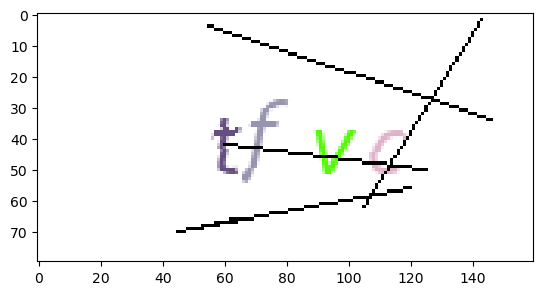

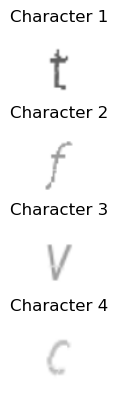

In [10]:
img = cv2.imread('train/tfvc-0.png')
plt.imshow(img)
plt.show()
char_count, char_segment = segment_characters(img)

for i, char_img in enumerate(char_segment):
    plt.subplot(char_count, 1, i + 1)
    plt.imshow(char_img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Character {i+1}')
    plt.axis('off')
plt.show()


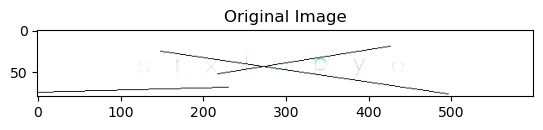

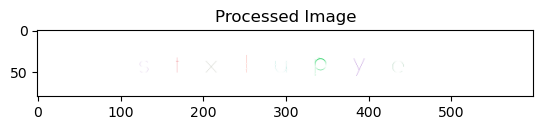

Detected 3 character segments.


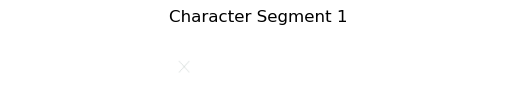

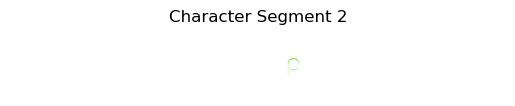

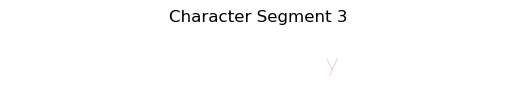

In [11]:
img = cv2.imread('train/stx1upye-0.png')
# img = cv2.imread('train/9thzh-0.png')
processed_img = remove_lines(img)
char_count, char_segments = segment_by_color(processed_img)
# char_count, char_segments = segment_characters(processed_img)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.show()

plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
plt.title('Processed Image')
plt.show()

print(f"Detected {char_count} character segments.")

for i, char_img in enumerate(char_segments):
    plt.imshow(char_img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Character Segment {i+1}')
    plt.axis('off')
    plt.show()

In [12]:
import os

train_dir = "cleaned_train/"

all_imgs = []
for (root, dirs, files) in os.walk(train_dir, topdown=True):
    for file in tqdm(files, desc=f"Loading '{train_dir}' images"):
        if not file.endswith('.png'): # Remove non png
            print(file, "is not png")
            continue
        if file.split(".png")[0].endswith('(1)'): # Remove duplicate data
            print(file, "is duplicate data")
            continue
        if file.endswith('badwrong.png'): # Remove known bad data
            continue
        if file.endswith('badcrop.png'):
            continue
        
        img_path = os.path.join(root, file)
        img = cv2.imread(img_path)
        filename = file.split(".")[0].split("-")[0]
        all_imgs.append((filename, remove_lines(img)))

Loading 'cleaned_train/' images:  63%|██████▎   | 5064/8001 [00:06<00:03, 822.93it/s]

.gitignore is not png


Loading 'cleaned_train/' images: 100%|██████████| 8001/8001 [00:09<00:00, 807.09it/s]


In [13]:
segmented_character_dir = "segmented_characters"
error_count = 0
skip_count = 0
error_files = []
max_length = 0

if not os.path.exists(segmented_character_dir):
    os.makedirs(segmented_character_dir)

for filename, img in tqdm(all_imgs, desc="Segmenting characters and saving images"):
    max_length = max(max_length, len(filename))
    try:
        char_count, char_segments = segment_characters(img)
        
        folder_path = os.path.join(segmented_character_dir, filename)
        
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)

        if char_count != len(filename):
            skip_count += 1
            continue

        filename_count = dict()

        for i, char_img in enumerate(char_segments):
            if filename[i] not in filename_count:
                filename_count[filename[i]] = 0
            else:
                filename_count[filename[i]] += 1

            cur_filename = f"{filename[i]}-{filename_count[filename[i]]}.png"
            char_path = os.path.join(folder_path, cur_filename)
            cv2.imwrite(char_path, char_img)
    except Exception as e:
        error_count += 1
        error_files.append(filename)


print(f"Total skipped: {skip_count}")
print(f"Total errors: {error_count}")
print(f"Max length: {max_length}")
with open("segmentation_errors.txt", "w") as f:
    for ef in error_files:
        f.write(ef + "\n")

Segmenting characters and saving images: 100%|██████████| 7817/7817 [01:53<00:00, 69.05it/s]

Total skipped: 953
Total errors: 101
